# SpillNet XAI Overlay Figure (Local)
Outputs one figure: the original SAR image and its Grad-CAM (oil-spill class) overlay, side by side.

**Instructions:**
1. Run all cells from top to bottom
2. To change sample: update `SAMPLE_NUMBER` in Cell 2 and re-run all cells

In [1]:
# ── Cell 1: PATHS ────────────────────────────────────────────────────────────
# Inside Docker these come from docker-compose.yml; otherwise the Windows defaults apply.
import os
DATA_DIR   = os.environ.get('SPILLNET_DATA_DIR',   r'C:\Users\Umaha\Documents\phd\Oil_Spill_Detection_Dataset')
MODEL_PATH = os.environ.get('SPILLNET_MODEL_PATH', r'C:\Users\Umaha\Documents\GitHub\phd\best_model.keras')

print('DATA_DIR   exists:', os.path.exists(DATA_DIR))
print('MODEL_PATH exists:', os.path.exists(MODEL_PATH))

DATA_DIR   exists: True
MODEL_PATH exists: True


In [2]:
# ── Cell 2: USER SETTINGS — only change the number ───────────────────────────
SAMPLE_NUMBER = '0017'   # <-- change ONLY this number
XAI_CLASS_IDX = 1        # class explained by Grad-CAM (1 = Oil Spill)
OVERLAY_ALPHA = 0.45     # heatmap opacity on top of the SAR image

IMAGE_FILENAME = f'img_{SAMPLE_NUMBER}.jpg'
OUTPUT_DIR     = os.path.join('results', 'xai_overlay')
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH    = os.path.join(OUTPUT_DIR, f'xai_overlay_{SAMPLE_NUMBER}.png')
print(f'Image : {IMAGE_FILENAME}')
print(f'Output: {OUTPUT_PATH}')

Image : img_0017.jpg
Output: xai_overlay_0017.png


In [3]:
# ── Cell 3: Imports ───────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.layers import Layer, GlobalAveragePooling2D, Dense, Reshape, Multiply
print('✅ Imports OK')

2026-10-03 04:08:42.243567: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Imports OK


In [4]:
# ── Cell 4: Custom objects needed to load SpillNet model ─────────────────────
class SimplifiedAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.global_pool = None
        self.fc1 = None
        self.fc2 = None

    def build(self, input_shape):
        channels = input_shape[-1]
        self.global_pool = GlobalAveragePooling2D(name=f'{self.name}_gap')
        self.fc1 = Dense(channels // 4, activation='relu', name=f'{self.name}_fc1')
        self.fc2 = Dense(channels, activation='sigmoid', name=f'{self.name}_fc2')
        self.fc1.build((None, channels))
        self.fc2.build((None, channels // 4))
        super().build(input_shape)

    def call(self, inputs):
        avg_pool = self.global_pool(inputs)
        attention = self.fc1(avg_pool)
        attention = self.fc2(attention)
        attention = Reshape((1, 1, -1))(attention)
        return Multiply()([inputs, attention])

    def get_config(self):
        return super().get_config()

    def compute_output_shape(self, input_shape):
        return input_shape

def oil_spill_recall(y_true, y_pred):
    y_pred_classes = tf.argmax(y_pred, axis=-1)
    y_true_classes = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
    true_c1 = tf.equal(y_true_classes, 1)
    pred_c1 = tf.equal(y_pred_classes, 1)
    tp = tf.reduce_sum(tf.cast(tf.logical_and(true_c1, pred_c1), tf.float32))
    total = tf.reduce_sum(tf.cast(true_c1, tf.float32))
    return tf.cond(total > 0, lambda: tp / total, lambda: 0.0)

def oil_spill_precision(y_true, y_pred):
    y_pred_classes = tf.argmax(y_pred, axis=-1)
    y_true_classes = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
    true_c1 = tf.equal(y_true_classes, 1)
    pred_c1 = tf.equal(y_pred_classes, 1)
    tp = tf.reduce_sum(tf.cast(tf.logical_and(true_c1, pred_c1), tf.float32))
    total = tf.reduce_sum(tf.cast(pred_c1, tf.float32))
    return tf.cond(total > 0, lambda: tp / total, lambda: 0.0)

def weighted_loss_fn(y_true, y_pred):
    class_weights = tf.constant([1.0, 15.0, 3.0, 30.0, 3.0], dtype=tf.float32)
    y_true_int = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
    sample_weights = tf.gather(class_weights, y_true_int)
    base_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return tf.reduce_mean(base_loss * sample_weights)

custom_objects = {
    'SimplifiedAttention': SimplifiedAttention,
    'oil_spill_recall': oil_spill_recall,
    'oil_spill_precision': oil_spill_precision,
    'loss_fn': weighted_loss_fn,
}
print('✅ Custom objects defined')

✅ Custom objects defined


In [5]:
# ── Cell 5: Config ────────────────────────────────────────────────────────────
IMG_SIZE    = 224
CLASS_NAMES = ['Sea Surface', 'Oil Spill', 'Look-alike', 'Ship', 'Land']
print('✅ Config OK')

✅ Config OK


In [6]:
# ── Cell 6: Find image ────────────────────────────────────────────────────────
IMG_PATH = None
for split in ['test', 'train']:
    candidate_img = os.path.join(DATA_DIR, split, 'images', IMAGE_FILENAME)
    if os.path.exists(candidate_img):
        IMG_PATH = candidate_img
        print(f'✅ Found in {split} split: {IMG_PATH}')
        break

if IMG_PATH is None:
    raise FileNotFoundError(f'Image not found in test/ or train/: {IMAGE_FILENAME}')

✅ Found in test split: /data/Oil_Spill_Detection_Dataset/test/images/img_0017.jpg


In [7]:
# ── Cell 7: Load model ────────────────────────────────────────────────────────
print('Loading model...')
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects)
print('✅ Model loaded')

Loading model...
✅ Model loaded


In [8]:
# ── Cell 8: Load image and compute Grad-CAM ──────────────────────────────────
img_pil     = Image.open(IMG_PATH).convert('RGB')
img_resized = img_pil.resize((IMG_SIZE, IMG_SIZE))
img_array   = np.array(img_resized, dtype=np.float32) / 255.0
img_batch   = img_array[np.newaxis, ...]

def grad_cam(m, img_batch, class_idx=1):
    # Same logic as the patched grad_cam_spillnet: last Conv2D, mean class score,
    # unwrapping list/tuple outputs before indexing.
    last_conv = next(l for l in reversed(m.layers) if isinstance(l, tf.keras.layers.Conv2D))
    model_output = m.output[0] if isinstance(m.output, (list, tuple)) else m.output
    grad_model = tf.keras.Model(inputs=m.inputs, outputs=[last_conv.output, model_output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch)
        if isinstance(conv_outputs, (list, tuple)):
            conv_outputs = conv_outputs[0]
        if isinstance(predictions, (list, tuple)):
            predictions = predictions[0]
        loss = tf.reduce_mean(predictions[:, :, :, class_idx])

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = tf.reduce_sum(pooled_grads * conv_outputs[0], axis=-1)
    heatmap      = tf.maximum(heatmap, 0)
    if tf.reduce_max(heatmap) > 0:
        heatmap = heatmap / tf.reduce_max(heatmap)
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], (IMG_SIZE, IMG_SIZE))
    return heatmap.numpy().squeeze()

print('Computing Grad-CAM...')
heatmap = grad_cam(model, img_batch, class_idx=XAI_CLASS_IDX)
print(f'✅ Grad-CAM complete (class {XAI_CLASS_IDX}: {CLASS_NAMES[XAI_CLASS_IDX]})')

Computing Grad-CAM...


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_image']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


✅ Grad-CAM complete (class 1: Oil Spill)


✅ Figure saved to: xai_overlay_0017.png


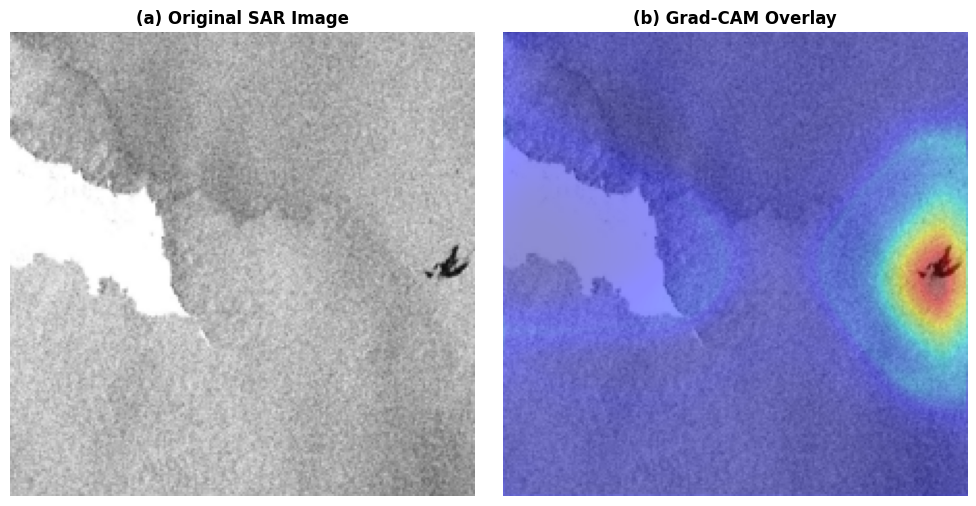

In [9]:
# ── Cell 9: Original SAR image and XAI overlay, side by side ─────────────────
fig, (ax_sar, ax_xai) = plt.subplots(1, 2, figsize=(10, 5))
fig.patch.set_facecolor('white')

ax_sar.imshow(img_resized)
ax_sar.set_title('(a) Original SAR Image', fontsize=12, fontweight='bold')
ax_sar.axis('off')

ax_xai.imshow(img_resized)
ax_xai.imshow(heatmap, cmap='jet', alpha=OVERLAY_ALPHA, vmin=0, vmax=1)
ax_xai.set_title('(b) Grad-CAM Overlay', fontsize=12, fontweight='bold')
ax_xai.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight', facecolor='white')
print(f'✅ Figure saved to: {OUTPUT_PATH}')
plt.show()